In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from inference import main

/home/hugoa/Documents/projects/skripsi-code/ai/.venv/lib/python3.12/site-packages/mlflow/utils/autologging_utils/versioning.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [2]:
MOCK_TRACK_NUM = "001"

# Create mock manifest, we don't care about accuracy, we just want to see the visuals after feed forward
mockfest = {"split": "test", "tags": ["mood/theme---action"], "track_id": f"track_{MOCK_TRACK_NUM}"}

os.makedirs("./temp/mock", exist_ok=True)

with open(f"./temp/mock/15_{MOCK_TRACK_NUM}_0.json", "w") as f:
    f.write(json.dumps(mockfest))

In [3]:
MULTI_LABEL = False

df = pd.read_csv("../prep/autotagging_moodtheme-test_clean.csv")
npy_dir = "./temp/raw/test"

all_tags = set()
for tags_str in df["TAGS"].dropna():
    tags = tags_str.split("+")
    for tag in tags:
        all_tags.add(tag)

vocab = sorted(list(all_tags))

all_mean_specs = {}

for tag in vocab:
    tag_tracks = []
    if MULTI_LABEL:
        for i, t in df["TAGS"].items():
            if tag in t:
                tag_tracks.append(df.iloc[i]["TRACK_ID"])  # type: ignore
    else:
        tag_tracks = df[df["TAGS"] == tag]["TRACK_ID"].values

    chunks = []
    for track_id in tag_tracks:
        subfolder = df[df["TRACK_ID"] == track_id]["PATH"].values[0].split("/")[0]

        track_id_num = track_id.replace("track_", "")

        chunk_files = list(
            Path(npy_dir).glob(f"15_melspec{subfolder}/15_{track_id_num}_*.npy")
        )
        for f in chunk_files:
            chunks.append(np.load(f))

    if len(chunks) == 0:
        print(f"No single-label chunks found for '{tag}'")
        continue

    chunks = np.array(chunks)

    mean_spec = np.mean(chunks, axis=0)
    mean_spec_loc = f"./temp/mock/15_{tag.replace("mood/theme---", "")}_{MOCK_TRACK_NUM}"
    np.save(mean_spec_loc, mean_spec)
    all_mean_specs.update({tag: mean_spec_loc})
    break

print(len(all_mean_specs))

1


In [11]:
aso = main(
    # json_config_path="./params_cnn_f2.json",
    # json_config_path="./params_gru_f2.json",
    json_config_path="./params_attn_f2.json",
    # previous_run_id="0d0be9c5ee5e44b8a2fab97582a6ff7b",  # CNN
    # previous_run_id="17e64b9ee037445d82075c4abd671dec",  # GRU
    previous_run_id="4e7c7f09ba9b4490bd4c8008ffead321",  # ATNN
    # artifact_file_name="BEST_CNN_model_epoch_17",
    # artifact_file_name="BEST_GRU_model_epoch_7",
    artifact_file_name="BEST_ATTN_model_epoch_13",
    # path_val="00/13400.mp3",
    # path_val="74/1158174.mp3",
    input_path=f"00/{MOCK_TRACK_NUM}.mp3",
    show_result=False,
    first_layer_only=True,
    skip_global_pooling=True,
    classify=False,
    custom_input=True
)

Muat checkpoint pada model terbaik: /home/hugoa/Documents/projects/skripsi-code/ai/temp/model/inference/4e7c7f09ba9b4490bd4c8008ffead321/BEST_ATTN_model_epoch_13.pth/training_checkpoints/BEST_ATTN_model_epoch_13.pth...
Inferensi pada: cuda
Pelabelan:
['action', 'adventure', 'advertising', 'background', 'ballad', 'calm', 'children', 'christmas', 'commercial', 'cool', 'corporate', 'dark', 'deep', 'documentary', 'drama', 'dramatic', 'dream', 'emotional', 'energetic', 'epic', 'fast', 'film', 'fun', 'funny', 'game', 'groovy', 'happy', 'heavy', 'holiday', 'hopeful', 'inspiring', 'love', 'meditative', 'melancholic', 'melodic', 'motivational', 'movie', 'nature', 'party', 'positive', 'powerful', 'relaxing', 'retro', 'romantic', 'sad', 'sexy', 'slow', 'soft', 'soundscape', 'space', 'sport', 'summer', 'trailer', 'travel', 'upbeat', 'uplifting']

Pemuatan model berhasil. Epoch: 13

Inferensi pada berkas musik: 00/001.mp3...


In [12]:
# aso[0].squeeze(2).shape
aso[0].shape

(469, 92)

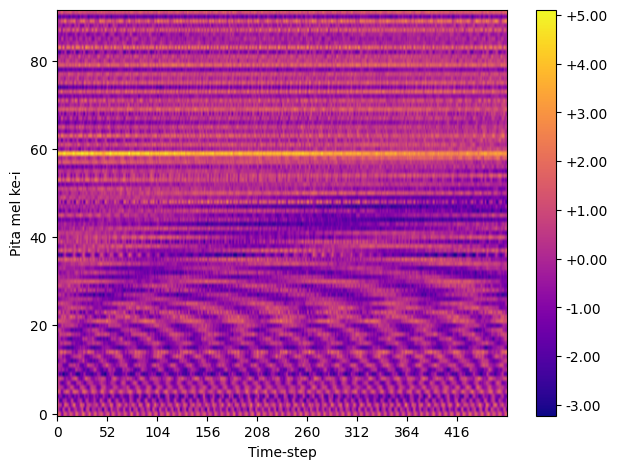

In [13]:
# to_plot = aso[0].squeeze(2).to_device("cpu")
to_plot = aso[0].transpose().to_device("cpu")

plt.imshow(
    to_plot,
    aspect="auto",
    origin="lower",
    cmap="plasma",
)
plt.xlabel("Time-step")
plt.xticks(np.arange(0, 468, 52))
plt.ylabel("Pita mel ke-i")
# plt.yticks(np.arange(0, 96, 19))
plt.colorbar(format="%+.2f")
plt.tight_layout()
plt.show()